In [8]:
import torch
import torchvision
from torchvision import transforms
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.transforms import functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

In [9]:
def load_image(image_path):
    image = Image.open(image_path)

    transform = transforms.Compose([transforms.ToTensor()])
    return transform(image).unsqueeze(0)

In [10]:
# Load the Model
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 147MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [19]:
load_image('jungle.jpg');

In [12]:
def predict(image):
  image_tensor = load_image(image)
  with torch.no_grad():
    prediction = model(image_tensor)
    return prediction

In [13]:
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter',
    'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra',
    'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon',
    'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet',
    'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster',
    'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

In [14]:
prediction = predict('jungle.jpg')
prediction

[{'boxes': tensor([[414.7507, 214.3974, 621.4139, 294.1198],
          [ 46.5356, 231.3264, 160.5595, 393.5677],
          [ 98.1405, 233.7098, 217.2793, 348.0531],
          [255.1284, 237.6299, 342.9709, 270.3036]]),
  'labels': tensor([25, 24, 24, 24]),
  'scores': tensor([0.9993, 0.9992, 0.9987, 0.9966])}]

In [15]:
COCO_INSTANCE_CATEGORY_NAMES [prediction[0]['labels'][0] - 1]

'giraffe'

In [16]:
COCO_INSTANCE_CATEGORY_NAMES [prediction[0]['labels'][1] - 1]

'zebra'

In [17]:
from torchvision.ops import boxes
def visualize_prediction(image, prediction):
  image = plt.imread(image)
  plt.imshow(image)

  boxes = prediction[0]['boxes'].cpu().numpy().astype(np.int32)
  labels = prediction[0]['labels'].cpu().numpy().astype(np.int32)
  scores = prediction[0]['scores'].cpu().numpy()

  for box, label, score in zip(boxes, labels, scores):
    box = box.tolist()
    x1, y1, x2, y2 = box
    label = COCO_INSTANCE_CATEGORY_NAMES[label - 1]
    plt.gca().add_patch(plt.Rectangle(
        (x1, y1), x2 - x1, y2 - y1, fill=False, color='red', linewidth=2))
    plt.text(x1, y1, f'{label}: {score:.2f}',
             fontsize=12, color='white')

  plt.axis('off')
  plt.show()

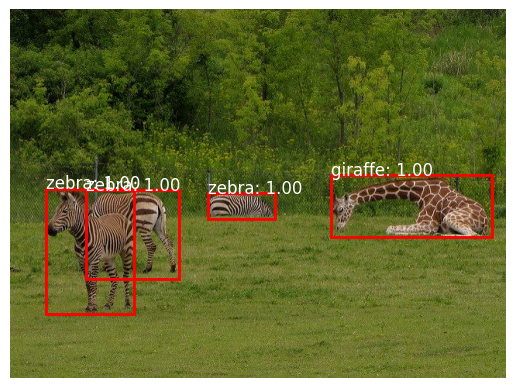

In [18]:
visualize_prediction('jungle.jpg', prediction)